### This was a heavy work, Done on kaggle

In [3]:
!pip3 install tldextract

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 4.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from urllib.parse import urlunparse, unquote, urlparse
from tqdm import tqdm
from collections import Counter
import re
import tldextract
import zlib

tqdm.pandas()

# benign_path = '/kaggle/input/datasets/yassineramla/benign-malicious-urls/benign.csv'
# malicious_path = '/kaggle/input/datasets/yassineramla/benign-malicious-urls/malicious.csv'
data_path = '/kaggle/working/data.csv'

In [3]:
# malicious_df = pd.read_csv(malicious_path, index_col=0)
# benign_df = pd.read_csv(benign_path, index_col=0)

In [4]:
# # labeling data
# benign_df['malicious'] = 0
# malicious_df['malicious'] = 1

In [5]:
# # concatinating dfs
# df = pd.concat([benign_df, malicious_df], ignore_index=True)
# df.shape

(4297145, 2)

In [4]:
# feature extraction functions
def alpha_digit_transitions(s):
    count = 0

    for a, b in zip(s, s[1:]):
        if (a.isalpha() and b.isdigit()) or \
           (a.isdigit() and b.isalpha()):
            count += 1

    return count

def digit_symbol_transitions(s):
    count = 0

    for a, b in zip(s, s[1:]):
        if (a.isdigit() and not b.isalnum()) or \
           (not a.isalnum() and b.isdigit()):
            count += 1

    return count

def alnum_symbol_transitions(s):
    count = 0

    for a, b in zip(s, s[1:]):
        if (a.isalnum() and not b.isalnum()) or \
           (not a.isalnum() and b.isalnum()):
            count += 1

    return count


def shannon_entropy(s):
    if not s:
        return np.float16(0.0)
    counts = Counter(s)
    length = len(s)
    return np.float16(-sum((c / length) * np.log2(c / length) for c in counts.values()))

def extract_url_structure_features(url):
    """
    Focusing on the url structure like lengths, transitions, ratios and entropy
    It focuses on each part of the url independently instead of treating the url as whole
    """
    parsed = urlparse(url)
    tld_info = tldextract.extract(url)

    parts = {
        'hostname':                        (parsed.hostname or '').lower(),
        'subdomain':                       (tld_info.subdomain                      or '').lower(),
        'domain':                          (tld_info.domain                         or '').lower(),
        'suffix':                          (tld_info.suffix                         or '').lower(),
        'top_domain_under_public_suffix':  (tld_info.top_domain_under_public_suffix or '').lower(),
    
        'path':                            parsed.path     or '',
        'query':                           parsed.query    or '',
        'fragment':                        parsed.fragment or '',
    }

    features = {}

    # lengths
    for key, val in parts.items():
        features[f'{key}_length'] = len(val)

    # transitions
    for key, val in parts.items():
        features[f'{key}_alpha_digit_transitions'] = alpha_digit_transitions(val) 
        features[f'{key}_digit_symbol_transitions'] = digit_symbol_transitions(val)
        features[f'{key}_alnum_symbol_transitions'] = alnum_symbol_transitions(val)

    # flags
    features['has_https'] = int(bool(parsed.scheme == 'https'))

    try:
        features['has_port'] = int(bool(parsed.port))
    except ValueError:
        features['has_port'] = int(0)

    features['has_params'] = int(bool(parsed.params))
    
    features['has_base64_like'] = int(
        bool(re.search(r'[A-Za-z0-9+/]{20,}={0,2}', url))
    )

    # path structure
    path_segments = [s for s in parts['path'].split('/') if s]
    path_segments_num = len(path_segments)
    avg_path_segment_len = np.mean([len(s) for s in path_segments]) if path_segments else 0
    max_path_segment_len = max([len(s) for s in path_segments]) if path_segments else 0
    min_path_segment_len = min([len(s) for s in path_segments]) if path_segments else 0

    features['path_segments_num'] = path_segments_num
    features['avg_path_segment_len'] = avg_path_segment_len
    features['max_path_segment_len'] = max_path_segment_len
    features['min_path_segment_len'] = min_path_segment_len

    # query structure
    query_params = parts['query'].split('&') if parts['query'] else []
    query_params_num = len(query_params)
    avg_query_param_len = np.mean([len(p) for p in query_params]) if query_params else 0
    max_query_param_len = max([len(p) for p in query_params]) if query_params else 0
    min_query_param_len = min([len(p) for p in query_params]) if query_params else 0

    features['query_params_num'] = query_params_num
    features['avg_query_param_len'] = avg_query_param_len
    features['max_query_param_len'] = max_query_param_len
    features['min_query_param_len'] = min_query_param_len

    # digits
    for key in ['hostname', 'subdomain', 'domain', 'top_domain_under_public_suffix', 'path', 'query', 'fragment']:
        digits_num = sum(c.isdigit() for c in parts[key])
        features[f'digits_{key}'] = digits_num
        features[f'digits_ratio_{key}'] = (digits_num / len(parts[key])) if parts[key] else 0

    # special chars
    for key, val in parts.items():
        special_chars = len(re.findall(r"[^a-zA-Z0-9]", val))
        features[f'special_chars_{key}'] = special_chars
        features[f'special_chars_ratio_{key}'] = (special_chars / len(val)) if val else 0

    for key in ['path', 'query', 'fragment']:
        features[f'num_ats_{key}'] = parts[key].count('@')
        features[f'num_dots_{key}'] = parts[key].count('.')
        features[f'num_underscores_{key}'] = parts[key].count('_')
        features[f'num_percent_{key}'] = parts[key].count('%')

    # chars repetition
    for key, val in parts.items():
        features[f'max_char_repeat_{key}'] = max((len(m.group()) for m in re.finditer(r'(.)\1+', val)), default=0)

    # caps
    for key in ['path', 'query', 'fragment']:
        caps_num = sum([c.isupper() for c in parts[key]])
        features[f'caps_{key}'] = caps_num
        features[f'caps_ratio_{key}'] = caps_num / len(parts[key]) if parts[key] else 0

    # typosquatting patterns
    for key in ['hostname', 'domain', 'subdomain', 'top_domain_under_public_suffix']:
        features[f'num_rn_pattern_{key}'] = parts[key].count('rn')
        features[f'num_0_{key}'] = parts[key].count('0')
        features[f'num_1_{key}'] = parts[key].count('1')
    
    # tokens
    for key in ['hostname', 'path', 'query', 'fragment']:
        features[f'num_tokens_{key}'] = len(re.split('[^a-zA-Z0-9]+', parts[key])) if parts[key] else 0

    # subdomain length
    features['longest_subdomain_len'] = max(
        (len(s) for s in parts['subdomain'].split('.')), default=0
    )

    # compression ratio
    features['compression_ratio'] = len(zlib.compress(url.encode())) / len(url) if url else 0

    # entropy
    for key, val in parts.items():
        features[f'{key}_entropy'] = shannon_entropy(val)

    return features

def extract_path_pollution_features(url):
    """
    Detect malformed/suspicious path patterns.
    """
    path = urlparse(url).path

    if not path or path == '/':
        return {
            'consecutive_slashes': 0,
            'double_dots': 0,
            'empty_segments': 0,
            'suspicious_extensions': 0,
        }
    
    # Consecutive slashes (e.g., //admin//login)
    consecutive_slashes = len(re.findall(r'//', path))
    
    # Directory traversal attempts (../)
    double_dots = path.count('..')
    
    # Empty segments between slashes
    segments = path.split('/')
    empty_segments = sum(1 for s in segments if not s)
    
    # Multiple extensions (e.g., file.pdf.exe)
    extension_pattern = r'\.[a-z0-9]{2,4}'
    extensions = re.findall(extension_pattern, path, re.IGNORECASE)
    suspicious_extensions = 1 if len(extensions) > 1 else 0
    
    return {
        'consecutive_slashes': consecutive_slashes,
        'double_dots': double_dots,
        'empty_segments': empty_segments - 1,  # -1 because path always starts with /
        'suspicious_extensions': suspicious_extensions,
    }

def extract_query_pollution_features(url):
    """
    Detect malformed/suspicious query string patterns.
    """
    query = urlparse(url).query

    if not query:
        return {
            'duplicate_keys': 0,
            'empty_values': 0,
            'empty_keys': 0,
            'max_key_frequency': 0,
            'suspicious_key_value_ratio': 0,
        }
    
    # Parse query parameters
    params_list = query.split('&')
    keys = []
    values = []
    empty_values = 0
    empty_keys = 0
    
    for param in params_list:
        if '=' in param:
            key, value = param.split('=', 1)  # Split only on first =
            keys.append(key)
            values.append(value)
            
            if not key:
                empty_keys += 1
            if not value:
                empty_values += 1
        else:
            # Key without value (e.g., ?debug&verbose)
            keys.append(param)
            empty_values += 1
    
    # Count duplicate keys
    key_counts = Counter(keys)
    duplicate_keys = sum(1 for count in key_counts.values() if count > 1)
    max_key_frequency = max(key_counts.values()) if key_counts else 0
    
    # Suspicious ratio: if you have way more keys than actual content
    total_keys_len = sum(len(k) for k in keys)
    total_values_len = sum(len(v) for v in values)
    suspicious_ratio = total_keys_len / max(total_values_len, 1)
    
    return {
        'duplicate_keys': duplicate_keys,
        'empty_values': empty_values,
        'empty_keys': empty_keys,
        'max_key_frequency': max_key_frequency,
        'suspicious_key_value_ratio': suspicious_ratio,
    }

In [9]:
# # url_structure_features = pd.DataFrame(
# #     df['url'].parallel_apply(extract_url_structure_features).tolist()
# # )

# out = np.empty((len(df), len(extract_url_structure_features(''))), np.float16)

# for i, url in enumerate(tqdm(df['url'], desc='Structure Features: ')):
#     out[i] = list(extract_url_structure_features(url).values())

# url_structure_features = pd.DataFrame(out, columns=list(extract_url_structure_features('').keys()), dtype=np.float16)
# # the warning is because of very small number (<10e-8) found so it rounds it to 0, no cast to inf
# url_structure_features.head()

Structure Features: 100%|██████████| 4297140/4297140 [16:58<00:00, 4217.61it/s]
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,hostname_length,subdomain_length,domain_length,suffix_length,top_domain_under_public_suffix_length,path_length,query_length,fragment_length,hostname_alpha_digit_transitions,hostname_digit_symbol_transitions,...,longest_subdomain_len,compression_ratio,hostname_entropy,subdomain_entropy,domain_entropy,suffix_entropy,top_domain_under_public_suffix_entropy,path_entropy,query_entropy,fragment_entropy
0,13.0,0.0,9.0,3.0,13.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.380859,3.392578,0.000000,2.724609,1.584961,3.392578,0.0,0.0,0.0
1,36.0,23.0,8.0,3.0,12.0,0.0,0.0,0.0,0.0,0.0,...,23.0,1.181641,3.830078,3.435547,2.750000,1.584961,3.189453,0.0,0.0,0.0
2,18.0,3.0,10.0,3.0,14.0,0.0,0.0,0.0,0.0,0.0,...,3.0,1.307617,2.974609,-0.000000,2.646484,1.584961,2.984375,0.0,0.0,0.0
3,13.0,0.0,10.0,2.0,13.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.380859,3.181641,0.000000,2.845703,1.000000,3.181641,0.0,0.0,0.0
4,11.0,0.0,7.0,3.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.420898,2.914062,0.000000,2.236328,1.584961,2.914062,0.0,0.0,0.0


In [10]:
# # path_pollution_features = pd.DataFrame(
# #     df['url'].parallel_apply(extract_path_pollution_features).tolist()
# # )

# out = np.empty((len(df), len(extract_path_pollution_features(''))), np.float16)

# for i, url in enumerate(tqdm(df['url'], desc='Path Pollution Features: ')):
#     out[i] = list(extract_path_pollution_features(url).values())

# path_pollution_features = pd.DataFrame(out, columns=list(extract_path_pollution_features('').keys()), dtype=np.float16)
# path_pollution_features.head()

Path Pollution Features: 100%|██████████| 4297140/4297140 [00:32<00:00, 133748.39it/s]
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,consecutive_slashes,double_dots,empty_segments,suspicious_extensions
0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0


In [11]:
# # query_pollution_features = pd.DataFrame(
# #     df['url'].parallel_apply(extract_query_pollution_features).tolist()
# # )

# out = np.empty((len(df), len(extract_query_pollution_features(''))), np.float16)

# for i, url in enumerate(tqdm(df['url'], desc='Query Pollution Features: ')):
#     out[i] = list(extract_query_pollution_features(url).values())

# query_pollution_features = pd.DataFrame(out, columns=list(extract_query_pollution_features('').keys()), dtype=np.float16)
# query_pollution_features

Query Pollution Features: 100%|██████████| 4297140/4297140 [00:27<00:00, 157102.86it/s]
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,duplicate_keys,empty_values,empty_keys,max_key_frequency,suspicious_key_value_ratio
0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...
4297135,0.0,0.0,0.0,0.0,0.000000
4297136,0.0,0.0,0.0,1.0,0.281250
4297137,0.0,0.0,0.0,1.0,0.600098
4297138,0.0,0.0,0.0,0.0,0.000000


In [ ]:
# df = pd.concat([df, url_structure_features, path_pollution_features, query_pollution_features], axis=1)

# df.to_csv('data.csv', index=False)
# df.head()

In [5]:
df = pd.read_csv(data_path)

df

,url,malicious,hostname_length,subdomain_length,domain_length,suffix_length,top_domain_under_public_suffix_length,path_length,query_length,fragment_length,...,fragment_entropy,consecutive_slashes,double_dots,empty_segments,suspicious_extensions,duplicate_keys,empty_values,empty_keys,max_key_frequency,suspicious_key_value_ratio
0,https://royal-lab.net,0,13.0,0.0,9.0,3.0,13.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
1,https://creepypastafromthecrypt.blogspot.com,0,36.0,23.0,8.0,3.0,12.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
2,https://www.gosnowmass.com,0,18.0,3.0,10.0,3.0,14.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
3,https://heilsarmee.ch,0,13.0,0.0,10.0,2.0,13.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
4,https://cineten.com,0,11.0,0.0,7.0,3.0,11.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4297135,https://vaneldangueldase.web.app,1,24.0,16.0,3.0,3.0,7.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
4297136,http://fbnotify-h43sls41f.liftcentr.uz/profile...,1,31.0,18.0,9.0,2.0,12.0,13.0,42.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.2812
4297137,https://authentifizierung.bkinginf.shop/cli/?p...,1,31.0,17.0,8.0,4.0,13.0,5.0,9.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.6000
4297138,http://117.209.16.14:54236/bin.sh,1,13.0,0.0,13.0,0.0,0.0,7.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000


In [19]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, GridSearchCV
import xgboost as xgb
from scipy.stats import uniform, randint
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

In [8]:
X, y = df.drop(columns=['malicious', 'url']), df['malicious']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [14]:
# # Randomized Search with CV
# param_dist = {
#     'max_depth':        randint(4, 12),
#     'learning_rate':    uniform(0.05, 0.25),
#     'n_estimators':     randint(200, 800),
#     'subsample':        uniform(0.6, 0.4),        # 0.6 to 1.0
#     'colsample_bytree': uniform(0.6, 0.4),        # 0.6 to 1.0
#     'min_child_weight': randint(1, 10),
#     'gamma':            uniform(0, 0.5),
#     'reg_alpha':        uniform(0, 1.0),
#     'reg_lambda':       uniform(0.5, 2.0),
# }

# base_clf = xgb.XGBClassifier(
#     tree_method='hist',
#     device='cuda',        # change to 'cpu' if GPU not enabled
#     eval_metric='logloss',
#     random_state=42,
# )

# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# search = RandomizedSearchCV(
#     estimator=base_clf,
#     param_distributions=param_dist,
#     n_iter=50,
#     scoring='f1',
#     cv=cv,
#     verbose=2,
#     random_state=42,
#     n_jobs=1,        # XGBoost handles its own parallelism, keep this at 1
#     refit=True,
# )

# # Sample if full dataset is too slow
# # X_search, _, y_search, _ = train_test_split(X_train, y_train, train_size=500_000, stratify=y_train, random_state=42)

# search.fit(X_train, y_train)

# print("Best params:", search.best_params_)
# print("Best CV F1:", search.best_score_)

# # The best model is already refit on full data
# best_clf = search.best_estimator_

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:00:56] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:00:56] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.749816047538945, gamma=0.4753571532049581, learning_rate=0.2329984854528513, max_depth=8, min_child_weight=5, n_estimators=321, reg_alpha=0.15599452033620265, reg_lambda=0.6161672243363989, subsample=0.9464704583099741; total time= 1.4min


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:02:19] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:02:19] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.749816047538945, gamma=0.4753571532049581, learning_rate=0.2329984854528513, max_depth=8, min_child_weight=5, n_estimators=321, reg_alpha=0.15599452033620265, reg_lambda=0.6161672243363989, subsample=0.9464704583099741; total time= 1.3min


...

[CV] END colsample_bytree=0.9621527905677054, gamma=0.04564333839306678, learning_rate=0.1298284093976037, max_depth=9, min_child_weight=4, n_estimators=705, reg_alpha=0.6318372121697993, reg_lambda=1.3968910439566395, subsample=0.7172843086792258; total time= 3.3min


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:24:37] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:24:37] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9621527905677054, gamma=0.04564333839306678, learning_rate=0.1298284093976037, max_depth=9, min_child_weight=4, n_estimators=705, reg_alpha=0.6318372121697993, reg_lambda=1.3968910439566395, subsample=0.7172843086792258; total time= 3.4min


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:28:07] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:28:07] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'colsample_bytree': np.float64(0.7043574493366855), 'gamma': np.float64(0.007652270145192375), 'learning_rate': np.float64(0.28335907701987073), 'max_depth': 11, 'min_child_weight': 1, 'n_estimators': 524, 'reg_alpha': np.float64(0.6839637693981411), 'reg_lambda': np.float64(1.7317023287798277), 'subsample': np.float64(0.9775566418243029)}
Best CV F1: 0.9503173679281075


In [15]:
# # The result of Randomized Search
# results = pd.DataFrame(search.cv_results_)
# results.sort_values('mean_test_score', ascending=False).head(10)[
#     ['mean_test_score', 'std_test_score', 'param_max_depth', 
#      'param_learning_rate', 'param_subsample', 'param_colsample_bytree']
# ]

,mean_test_score,std_test_score,param_max_depth,param_learning_rate,param_subsample,param_colsample_bytree
42,0.950317,0.000328,11,0.283359,0.977557,0.704357
26,0.949965,0.000266,11,0.173473,0.863045,0.670370
28,0.949846,0.000170,10,0.211276,0.828802,0.773758
36,0.949470,0.000321,11,0.260506,0.890437,0.986101
29,0.949207,0.000202,9,0.298638,0.971327,0.907422
24,0.948937,0.000326,9,0.264081,0.867595,0.880143
21,0.948645,0.000101,11,0.106624,0.974692,0.606635
47,0.948590,0.000137,10,0.195136,0.695294,0.651076
16,0.948556,0.000157,10,0.134404,0.988713,0.688843
49,0.948201,0.000222,9,0.129828,0.717284,0.962153


In [7]:
# # Grid Search with CV
# param_grid = {
#     'max_depth':        [11],
#     'learning_rate':    [0.20, 0.25, 0.30],
#     'subsample':        [0.85, 0.95],
#     'colsample_bytree': [0.65, 0.70, 0.75],
#     'reg_alpha':        [0.5, 0.7],
#     'reg_lambda':       [1.7, 2.0],
#     'n_estimators':     [524],
#     'min_child_weight': [1],
#     'gamma':            [0.007],
# }

# base_clf = xgb.XGBClassifier(
#     tree_method='hist',
#     device='cuda',
#     eval_metric='logloss',
#     random_state=42,
# )

# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# grid_search = GridSearchCV(
#     estimator=base_clf,
#     param_grid=param_grid,
#     scoring='f1',
#     cv=cv,
#     verbose=2,
#     n_jobs=1,
#     refit=True,
# )

# grid_search.fit(X_train, y_train)

# print("Best params:", grid_search.best_params_)
# print("Best CV F1:", grid_search.best_score_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
[CV] END colsample_bytree=0.65, gamma=0.007, learning_rate=0.2, max_depth=11, min_child_weight=1, n_estimators=524, reg_alpha=0.5, reg_lambda=1.7, subsample=0.85; total time= 1.1min
[CV] END colsample_bytree=0.65, gamma=0.007, learning_rate=0.2, max_depth=11, min_child_weight=1, n_estimators=524, reg_alpha=0.5, reg_lambda=1.7, subsample=0.85; total time= 1.0min
[CV] END colsample_bytree=0.65, gamma=0.007, learning_rate=0.2, max_depth=11, min_child_weight=1, n_estimators=524, reg_alpha=0.5, reg_lambda=1.7, subsample=0.85; total time= 1.0min
[CV] END colsample_bytree=0.65, gamma=0.007, learning_rate=0.2, max_depth=11, min_child_weight=1, n_estimators=524, reg_alpha=0.5, reg_lambda=1.7, subsample=0.95; total time=  58.5s
[CV] END colsample_bytree=0.65, gamma=0.007, learning_rate=0.2, max_depth=11, min_child_weight=1, n_estimators=524, reg_alpha=0.5, reg_lambda=1.7, subsample=0.95; total time=  58.7s
[CV] END colsample_bytree=0.

In [11]:
# Randomized Search Result
# Best params: {'colsample_bytree': np.float64(0.7043574493366855), 'gamma': np.float64(0.007652270145192375), 'learning_rate': np.float64(0.28335907701987073), 'max_depth': 11, 'min_child_weight': 1, 'n_estimators': 524, 'reg_alpha': np.float64(0.6839637693981411), 'reg_lambda': np.float64(1.7317023287798277), 'subsample': np.float64(0.9775566418243029)}
# Best CV F1: 0.9503173679281075

# Grid Search Result
# Best params: {'colsample_bytree': 0.7, 'gamma': 0.007, 'learning_rate': 0.2, 'max_depth': 11, 'min_child_weight': 1, 'n_estimators': 524, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'subsample': 0.95}
# Best CV F1: 0.9503964883637829

best_clf = xgb.XGBClassifier(
    colsample_bytree = 0.7,
    gamma = 0.007, 
    learning_rate = 0.2, 
    max_depth = 11, 
    min_child_weight = 1,
    n_estimators = 524, 
    reg_alpha = 0.5, 
    reg_lambda = 2.0, 
    subsample = 0.95
)

best_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.007, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=11,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=524,
              n_jobs=None, num_parallel_tree=None, ...)

In [11]:
best_clf.score(X_test, y_test)

# Accuracy results:
# new:
    # 0.9599151994117018
    # 0.9650123880844779
    # 0.9656663113916077
    # 0.9669741580058675
    # 0.969616225365398
    # 0.970843398167153
    # 0.9717090902321078
    # 0.9717354643631191
    # 0.9756745184006106
# with and with/:
    # lens + nums + ratios: 0.9661402700400732
    # lens + nums: 0.9658548088573641
    # lens + ratios: 0.966019259321316

    # num + avg + max + min (segs): 0.9540787593608773
    # num + avg + max (segs): 0.9531665247117851
    # num + avg (segs): 0.9510759869742821

0.975402244283407

Threshold | Precision | Recall | F1
0.3000      | 0.9372    | 0.9617 | 0.94930
0.3100      | 0.9387    | 0.9608 | 0.94965
0.3200      | 0.9404    | 0.9599 | 0.95004
0.3300      | 0.9418    | 0.9591 | 0.95038
0.3400      | 0.9433    | 0.9582 | 0.95070
0.3500      | 0.9445    | 0.9575 | 0.95095
0.3600      | 0.9458    | 0.9567 | 0.95124
0.3700      | 0.9471    | 0.9560 | 0.95153
0.3800      | 0.9483    | 0.9551 | 0.95169
0.3900      | 0.9493    | 0.9544 | 0.95183
0.4000      | 0.9504    | 0.9536 | 0.95199
0.4100      | 0.9514    | 0.9528 | 0.95213
0.4200      | 0.9526    | 0.9519 | 0.95223
0.4300      | 0.9539    | 0.9508 | 0.95232
0.4400      | 0.9549    | 0.9499 | 0.95237
0.4500      | 0.9560    | 0.9489 | 0.95241
0.4600      | 0.9570    | 0.9479 | 0.95243
0.4700      | 0.9581    | 0.9468 | 0.95240
0.4800      | 0.9594    | 0.9455 | 0.95236
0.4900      | 0.9610    | 0.9437 | 0.95226
0.5000      | 0.9621    | 0.9426 | 0.95225
0.5100      | 0.9633    | 0.9415 | 0.95226
0.5200      | 0.96

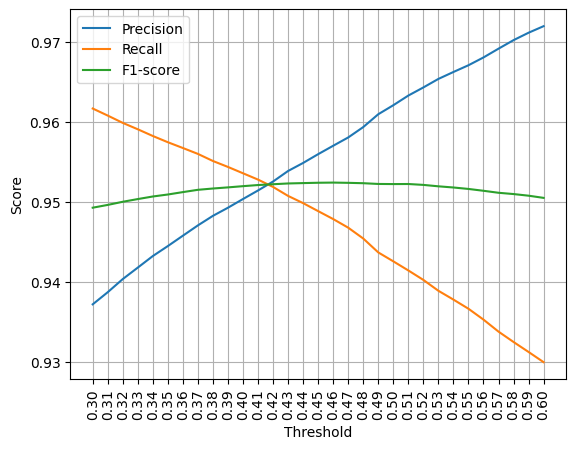

In [17]:
# Threshold Tunning
y_prob = best_clf.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.3, 0.6, 31)
results = []

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    results.append((t, precision, recall, f1))

# Print nicely
print("Threshold | Precision | Recall | F1")
for r in results:
    print(f"{r[0]:.2f}      | {r[1]:.4f}    | {r[2]:.4f} | {r[3]:.5f}")

results = np.array(results)
plt.plot(results[:,0], results[:,1], label="Precision")
plt.plot(results[:,0], results[:,2], label="Recall")
plt.plot(results[:,0], results[:,3], label="F1-score")
plt.xticks(thresholds, rotation=90)
plt.grid()
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [20]:
# We want a high Recall
THRESHOLD = 0.43

y_prob = best_clf.predict_proba(X_test)[:, 1] 
y_pred = (y_prob >= THRESHOLD).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# best clf result:
# Accuracy: 0.9752308124318345
# Precision: 0.9538829216057525
# Recall: 0.9507688913534754
# F1-score: 0.9523233608215713
# ROC-AUC: 0.9951242993042075

# Results history:
# new:
    #
    # Accuracy: 0.9596592151989463
    # Precision: 0.929745712596097
    # Recall: 0.9140207144518183
    # F1-score: 0.9218161563406263
    # ROC-AUC: 0.985940680943219

    #
    # Accuracy: 0.964917751496732
    # Precision: 0.9393147590817432
    # Recall: 0.9249205468996894
    # F1-score: 0.9320620823919626
    # ROC-AUC: 0.9893285851896917

    #
    # Accuracy: 0.965408775759381
    # Precision: 0.9389824573055315
    # Recall: 0.9273115932955298
    # F1-score: 0.9331105334447333
    # ROC-AUC: 0.9897909027978944

    #
    # Accuracy: 0.9668252217366279
    # Precision: 0.9431648510068659
    # Recall: 0.9284445080466761
    # F1-score: 0.9357467912458064
    # ROC-AUC: 0.9906328592116802

    #
    # Accuracy: 0.969593729783065
    # Precision: 0.9513814815040563
    # Recall: 0.9306984121305356
    # F1-score: 0.9409262987835019
    # ROC-AUC: 0.9925140497332802

    #
    # Accuracy: 0.9699606404880146
    # Precision: 0.9479886090131334
    # Recall: 0.9358949132127673
    # F1-score: 0.9419029430341291
    # ROC-AUC: 0.9928268152195641

    #
    # Accuracy: 0.9707045461244765
    # Precision: 0.9494217122150083
    # Recall: 0.9373408701977831
    # F1-score: 0.9433426147069767
    # ROC-AUC: 0.993129260705064

    #
    # Accuracy: 0.9716175564833044
    # Precision: 0.9484215233447679
    # Recall: 0.9421527765355467
    # F1-score: 0.9452767570170755
    # ROC-AUC: 0.9939543937053281

    #
    # Accuracy: 0.9716672019063842
    # Precision: 0.9508475650041179
    # Recall: 0.9396812335652828
    # F1-score: 0.9452314225435112
    # ROC-AUC: 0.9939306243902187

    #
    # Accuracy: 0.9716695290355911
    # Precision: 0.9510711763321039
    # Recall: 0.9394457065512286
    # F1-score: 0.9452226968395286
    # ROC-AUC: 0.993944354082995

    #
    # Accuracy: 0.9724723886119605
    # Precision: 0.9510254166177944
    # Recall: 0.9427490474572027
    # F1-score: 0.9468691469149609
    # ROC-AUC: 0.9943049131056229

    #
    # Accuracy: 0.9726725217237512
    # Precision: 0.9515491923862587
    # Recall: 0.9429845744712567
    # F1-score: 0.9472475243966536
    # ROC-AUC: 0.9943347949082221

    #
    # Accuracy: 0.9725507352952584
    # Precision: 0.952231373069178
    # Recall: 0.9417443309542124
    # F1-score: 0.9469588183625075
    # ROC-AUC: 0.9943132068631854

    #
    # Accuracy: 0.9728012895398644
    # Precision: 0.951850548048658
    # Recall: 0.9431753811661867
    # F1-score: 0.9474931077497196
    # ROC-AUC: 0.9943525111473009

    #
    # Accuracy: 0.9756365086235651
    # Precision: 0.9580422951985488
    # Recall: 0.9478739960288357
    # F1-score: 0.9529310210467633
    # ROC-AUC: 0.9950855663788699

    #
    # Accuracy: 0.9752184010760645
    # Precision: 0.9515090920452415
    # Recall: 0.9533388190258125
    # F1-score: 0.9524230767512409
    # ROC-AUC: 0.9950975169679679

    #
    # Accuracy: 0.9752308124318345
    # Precision: 0.9538829216057525
    # Recall: 0.9507688913534754
    # F1-score: 0.9523233608215713
    # ROC-AUC: 0.9951242993042075

# with and w/o:
    # lens + nums + ratios:
    # Accuracy: 0.9660060722558105
    # Precision: 0.9421415423059077
    # Recall: 0.9262293615727242
    # F1-score: 0.934117693044345
    # ROC-AUC: 0.9907165740785088

    # lens + nums:
    # Accuracy: 0.9657454337846413
    # Precision: 0.9444680130261347
    # Recall: 0.9225921089506228
    # F1-score: 0.9334019035783714
    # ROC-AUC: 0.9905615145247466

    # lens + ratios:
    # Accuracy: 0.9660083993850174
    # Precision: 0.9454189961201235
    # Recall: 0.9226219224967056
    # F1-score: 0.9338813546023527
    # ROC-AUC: 0.9906382105366351

    # num + avg + max + min (segs):
    # Accuracy: 0.9536893530735947
    # Precision: 0.9163965868760855
    # Recall: 0.9045310627336637
    # F1-score: 0.9104251657556793
    # ROC-AUC: 0.9826625455354189

    # num + avg + max (segs):
    # Accuracy: 0.9529291575326845
    # Precision: 0.9172278057714561
    # Recall: 0.900336296799814
    # F1-score: 0.9087035607732687
    # ROC-AUC: 0.9819542704562353

    # nums + avg (segs):
    # Accuracy: 0.9506167668107935
    # Precision: 0.9102547070687552
    # Recall: 0.8988187873041995
    # F1-score: 0.9045006015403032
    # ROC-AUC: 0.9800643502966174

    # no https flag:
    # Accuracy: 0.9536366048115723
    # Precision: 0.9482199594787524
    # Recall: 0.8692765444907549
    # F1-score: 0.9070337885026076
    # ROC-AUC: 0.9842198023916893

Accuracy: 0.9752308124318345
Precision: 0.9538829216057525
Recall: 0.9507688913534754
F1-score: 0.9523233608215713
ROC-AUC: 0.9951242993042075


In [59]:
FEATURE_COLUMNS = X_train.columns.tolist()

def predict_url(url, model, threshold=0.45):
    sFeatures = extract_url_structure_features(url)
    pFeatures = extract_path_pollution_features(url)
    qFeatures = extract_query_pollution_features(url)

    features = sFeatures | pFeatures | qFeatures
    
    # Convert to DataFrame to match training dtype
    X_df = pd.DataFrame([features], columns=FEATURE_COLUMNS, dtype=np.float32)
    
    prob = model.predict_proba(X_df)[0, 1]
    label = int(prob >= threshold)
    
    return {
        "url": url,
        "malicious": bool(label),
        "probability": prob
    }

test_urls = [
    "https://github.com/login",
    "http://192.168.1.10/login.php",
    "https://accounts.google.com.secure-login.xyz",
    "https://login.microsoftonline.com",
    "http://secure-google-account.top/auth",
    "https://bit.ly/3xKJ9sd",
    "https://myaccount.google.com/security",
    "https://github.io/someuser/repo",
    "https://example.com/login%3Fid%3D123"
    
    "https://openai.com",
    "https://chat.openai.com",
    "https://mail.google.com",
    "https://support.microsoft.com",
    "https://aws.amazon.com/console/",
    "https://developer.mozilla.org/en-US/",
    "https://docs.github.com/en/authentication",
    "https://accounts.google.com/signin/v2/identifier",
    "https://login.live.com/",
    "https://login.microsoftonline.com/common/oauth2/v2.0/authorize",

    "https://secure.bankofamerica.com/login/sign-in/signOnV2Screen.go",
    "https://signin.ebay.com/ws/eBayISAPI.dll?SignIn",
    "https://auth.atlassian.com/login",
    "https://myaccount.google.com/security-checkup",
    "https://support.apple.com/en-us/HT201487",

    "https://google.com.secure-auth-login.xyz",
    "https://paypal.com.user-session.ru/login",
    "https://microsoftonline.com.login.verify-account.cn",
    "https://amazon.aws.login-account-security.top",
    "https://github.com.secure-authenticate.xyz",
    "https://dropbox.com.file-share-security-alert.ru",
    "https://appleid.apple.com.manage-account.security-alert.cc",

    "https://micr0soft-login.com",
    "https://goog1e-authentication.com",

    "https://bit.ly/3xKJ9sd",
    "https://tinyurl.com/2p8x7w",
    "https://t.co/i/status/123456789",

    "http://192.168.1.1/login",
    "http://10.0.0.5/admin",
    "http://172.16.0.10/dashboard",
    "http://45.33.32.156/secure/login.php",

    "https://secure-update-login.zip",
    "https://paypal-security-review.top",
    "https://google-authentication.click",
    "https://microsoft-login.buzz",

    "https://example.com/" + "a"*200,
    "https://login-security-alert-paypal-account-update.example.com/login",

    "https://github.io",
    "https://raw.githubusercontent.com/user/repo/main/file.py",
    "https://storage.googleapis.com/mybucket/index.html",
    "https://firebaseapp.com",
    "https://notion.so",
    "https://vercel.app",
    "https://herokuapp.com",

    "https://example.com:8080/login",
    "https://sub.sub.sub.sub.example.com",
    "https://example.travel",
    "https://example.museum",
    
    "https://this-is-actually-safe.com",
    "https://google.com---------------evil.com",
    "https://login.live.com.evil.co.uk",
]

for url in test_urls:
    unquoted_url = unquote(url)
    while unquoted_url != url:
        url = unquoted_url
        unquoted_url = unquote(url)
    result = predict_url(unquoted_url, best_clf)
    print(
        f"{result['url']}\n"
        f"  → malicious={result['malicious']} | p={result['probability']:.3f}\n"
    )

https://github.com/login
  → malicious=False | p=0.042

http://192.168.1.10/login.php
  → malicious=True | p=1.000

https://accounts.google.com.secure-login.xyz
  → malicious=True | p=0.999

https://login.microsoftonline.com
  → malicious=False | p=0.332

http://secure-google-account.top/auth
  → malicious=True | p=0.982

https://bit.ly/3xKJ9sd
  → malicious=True | p=0.992

https://myaccount.google.com/security
  → malicious=False | p=0.021

https://github.io/someuser/repo
  → malicious=False | p=0.004

https://example.com/login?id=123https://openai.com
  → malicious=False | p=0.002

https://chat.openai.com
  → malicious=False | p=0.163

https://mail.google.com
  → malicious=False | p=0.368

https://support.microsoft.com
  → malicious=False | p=0.275

https://aws.amazon.com/console/
  → malicious=False | p=0.053

https://developer.mozilla.org/en-US/
  → malicious=False | p=0.049

https://docs.github.com/en/authentication
  → malicious=False | p=0.043

https://accounts.google.com/signin

In [47]:
def unquoted(url):
    unquoted = unquote(url)
    while unquoted != url:
        url = unquoted
        unquoted = unquote(url)
    return unquoted

test_df = pd.read_csv('/kaggle/input/legitfish-for-test-raw/url_features_extracted1.csv').rename(columns={'URL': 'url', 'ClassLabel': 'malicious'})[['url', 'malicious']]
test_df['malicious'] = abs(test_df['malicious'] - 1)
test_df['malicious'] = test_df['malicious'].fillna(test_df['malicious'].mode()[0])
test_df['url'] = test_df['url'].apply(lambda url: url.rstrip('/'))
test_df = test_df[~test_df['url'].isin(df['url'])]
test_df['url'] = test_df['url'].progress_apply(unquoted)
test_df

100%|██████████| 95153/95153 [00:00<00:00, 964535.34it/s]


,url,malicious
4,https://scearmcoommunnlty.com/invent/freind/get,1.0
10,https://officalmetamask.gitbook.io/us,1.0
12,https://sjhjjhsjjnm.wixsite.com/my-site-1,1.0
14,http://sretyuj.weebly.com,1.0
15,https://meta_massk-logii.godaddysites.com,1.0
...,...,...
101210,https://www.bidforwine.co.uk,0.0
101212,https://www.cultureready.org,0.0
101215,https://www.eosc-synergy.eu,0.0
101216,https://www.activecyber.us,0.0


In [38]:
df['url'].isin(test_df['url']).sum()

np.int64(0)

In [41]:
test_sfeatures = test_df['url'].progress_apply(extract_url_structure_features).progress_apply(pd.Series)
test_pfeatures = test_df['url'].progress_apply(extract_path_pollution_features).progress_apply(pd.Series)
test_qfeatures = test_df['url'].progress_apply(extract_query_pollution_features).progress_apply(pd.Series)

test_features = pd.concat([test_sfeatures, test_pfeatures, test_qfeatures], axis=1)

100%|██████████| 95153/95153 [00:16<00:00, 5658.44it/s] 


In [50]:
y_prob_test = best_clf.predict_proba(test_features)[:, 1] 
y_pred_test = (y_prob_test >= THRESHOLD).astype(int)

print("Accuracy:", accuracy_score(test_df['malicious'], y_pred_test))
print("Precision:", precision_score(test_df['malicious'], y_pred_test))
print("Recall:", recall_score(test_df['malicious'], y_pred_test))
print("F1-score:", f1_score(test_df['malicious'], y_pred_test))
print("ROC-AUC:", roc_auc_score(test_df['malicious'], y_pred_test))

# Best Clf result:
# Accuracy: 0.9788656164282786
# Precision: 0.9910698482678724
# Recall: 0.9769072164948454
# F1-score: 0.983937571386353
# ROC-AUC: 0.9798095562896617

# Results history
# new:
    #
    # Accuracy: 0.9700747883302542
    # Precision: 0.9889394085969495
    # Recall: 0.9632060804974952
    # F1-score: 0.9759031352176991
    # ROC-AUC: 0.9952136098040281

    #
    # Accuracy: 0.9726335964591628
    # Precision: 0.9898663320947739
    # Recall: 0.9663939446285275
    # F1-score: 0.9779893204500667
    # ROC-AUC: 0.9946317416261768

    #
    # Accuracy: 0.9688501676247727
    # Precision: 0.9894431592323483
    # Recall: 0.9632672482157019
    # F1-score: 0.9761797608332262
    # ROC-AUC: 0.994439736906507

    #
    # Accuracy: 0.9697119376162602
    # Precision: 0.9903667481662591
    # Recall: 0.9636637589214909
    # F1-score: 0.9768327974276527
    # ROC-AUC: 0.9952791069526089

    #
    # Accuracy: 0.9698065221275209
    # Precision: 0.9895384214893513
    # Recall: 0.9646312450436162
    # F1-score: 0.9769261041015798
    # ROC-AUC: 0.9946166199828204

    #
    # Accuracy: 0.9808413817746157
    # Precision: 0.992439718821883
    # Recall: 0.9785408406026963
    # F1-score: 0.9854412739484255
    # ROC-AUC: 0.9819502321569381

    #
    # Accuracy: 0.9786028816747764
    # Precision: 0.9927000226105495
    # Recall: 0.9748770816812053
    # F1-score: 0.9837078292042762
    # ROC-AUC: 0.980398700327255

    #
    # Accuracy: 0.976805775960821
    # Precision: 0.9918195780454289
    # Recall: 0.9730214115781126
    # F1-score: 0.9823305712341379
    # ROC-AUC: 0.9786298223825212

    #
    # Accuracy: 0.9787500131367377
    # Precision: 0.9909260570178261
    # Recall: 0.9768754956383823
    # F1-score: 0.9838506141878185
    # ROC-AUC: 0.9796535220458988

    #
    # Accuracy: 0.9788656164282786
    # Precision: 0.9910698482678724
    # Recall: 0.9769072164948454
    # F1-score: 0.983937571386353
    # ROC-AUC: 0.9798095562896617

Accuracy: 0.9788656164282786
Precision: 0.9910698482678724
Recall: 0.9769072164948454
F1-score: 0.983937571386353
ROC-AUC: 0.9798095562896617
